In [1]:
!pip install transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.3 MB/s eta 0:00:00


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    SegformerImageProcessor,
    SegformerForSemanticSegmentation
)

In [3]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shenhaibb/swad-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.04G/1.04G [01:00<00:00, 18.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/shenhaibb/swad-dataset/versions/1


In [6]:
import shutil

drive_dataset_path = "/content/gdrive/MyDrive/swad_dataset"

shutil.copytree(
    path,
    drive_dataset_path,
    dirs_exist_ok=True
)

print("Dataset copied.")

Dataset copied.


In [7]:
dataset_path = "/content/gdrive/MyDrive/swad_dataset"

for root, dirs, files in os.walk(dataset_path):

    print("\nFOLDER:", root)

    print("Subfolders:", dirs[:5])

    print("Sample files:", files[:5])

    print("-" * 50)


FOLDER: /content/gdrive/MyDrive/swad_dataset
Subfolders: ['SWAD']
Sample files: []
--------------------------------------------------

FOLDER: /content/gdrive/MyDrive/swad_dataset/SWAD
Subfolders: ['labels', 'images']
Sample files: []
--------------------------------------------------

FOLDER: /content/gdrive/MyDrive/swad_dataset/SWAD/labels
Subfolders: ['test', 'train', 'val']
Sample files: ['val.cache', 'test.cache']
--------------------------------------------------

FOLDER: /content/gdrive/MyDrive/swad_dataset/SWAD/labels/test
Subfolders: []
Sample files: ['0152.txt', 'new_0933.txt', 'new_0395.txt', 'new_0349.txt', 'new_0448.txt']
--------------------------------------------------

FOLDER: /content/gdrive/MyDrive/swad_dataset/SWAD/labels/train
Subfolders: []
Sample files: ['new_0823.txt', '0941.txt', 'new_0964.txt', '0842.txt', 'new_0250.txt']
--------------------------------------------------

FOLDER: /content/gdrive/MyDrive/swad_dataset/SWAD/labels/val
Subfolders: []
Sample file

In [8]:
label_path = "/content/gdrive/MyDrive/swad_dataset/SWAD/labels/train"

sample_file = os.listdir(label_path)[0]

print("Sample label file:", sample_file)

with open(os.path.join(label_path, sample_file), "r") as f:

    content = f.read()

print("\nLabel content:\n")
print(content)

Sample label file: new_0823.txt

Label content:

0.0 0.6333333333333333 0.8681364392678869 0.13416666666666666 0.12728785357737105
0.0 0.5308333333333333 0.8169717138103162 0.029166666666666667 0.09317803660565724



In [9]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 66.2 MB/s eta 0:00:00


In [10]:
from ultralytics import YOLO
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [11]:
yaml_text = """
path: /content/gdrive/MyDrive/swad_dataset/SWAD

train: images/train
val: images/val

names:
  0: solid_waste
"""

with open("dataset.yaml", "w") as f:
    f.write(yaml_text)

print("dataset.yaml created")

dataset.yaml created


In [12]:
model = YOLO("yolov8n.pt")

In [13]:
model.train(
    data="dataset.yaml",
    epochs=10,
    imgsz=640,
    batch=8
)

Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e9c5853e6c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [14]:
import os

runs_dir = "/content/runs/detect"

print(os.listdir(runs_dir))

['train']


In [15]:
weights_path = "/content/runs/detect/train/weights"

print(os.listdir(weights_path))

['last.pt', 'best.pt']


In [16]:
from ultralytics import YOLO

model = YOLO(
    "/content/runs/detect/train/weights/best.pt"
)

print("YOLO model loaded.")

YOLO model loaded.


In [17]:
test_image = "/content/gdrive/MyDrive/swad_dataset/SWAD/images/val"

sample_image = os.listdir(test_image)[0]

sample_path = os.path.join(
    test_image,
    sample_image
)

print(sample_path)

/content/gdrive/MyDrive/swad_dataset/SWAD/images/val/new_0006.jpg


In [18]:
results = model(sample_path)


image 1/1 /content/gdrive/MyDrive/swad_dataset/SWAD/images/val/new_0006.jpg: 384x640 2 solid_wastes, 39.7ms
Speed: 2.3ms preprocess, 39.7ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)


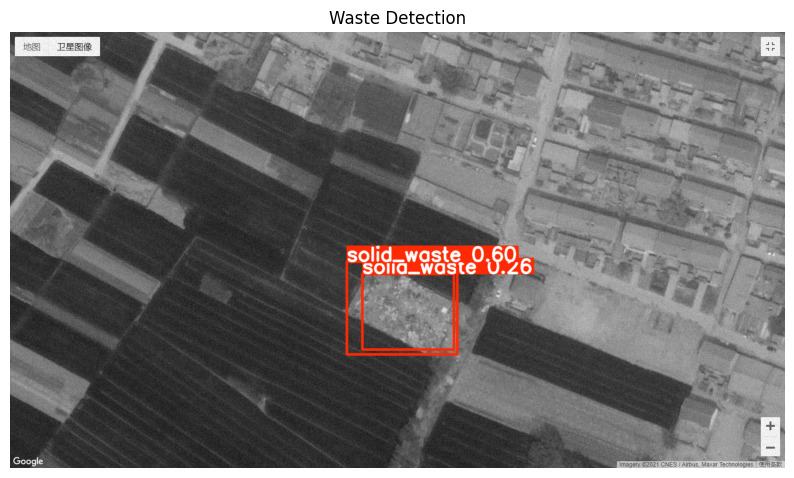

In [19]:
result_image = results[0].plot()

plt.figure(figsize=(10,10))

plt.imshow(result_image)

plt.axis("off")

plt.title("Waste Detection")

plt.show()

In [20]:
boxes = results[0].boxes

print("Total Waste Detections:", len(boxes))

Total Waste Detections: 2


In [21]:
for box in boxes:

    conf = float(box.conf[0])

    print("Confidence:", round(conf, 2))

Confidence: 0.6
Confidence: 0.26


In [22]:
waste_count = len(boxes)

alerts = []

if waste_count > 5:
    alerts.append(
        "Heavy solid waste accumulation detected."
    )

if waste_count > 10:
    alerts.append(
        "Potential illegal dumping region identified."
    )

print("Alerts:\n")

for alert in alerts:
    print("-", alert)

Alerts:



In [23]:
from PIL import Image

Image.fromarray(result_image).save(
    "waste_detection_result.png"
)

print("Detection image saved.")

Detection image saved.


In [24]:
from google.colab import files

files.download(
    "/content/runs/detect/train/weights/best.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
import shutil

shutil.copy(
    "/content/runs/detect/train/weights/best.pt",
    "/content/gdrive/MyDrive/waste_yolo_best.pt"
)

print("YOLO model backed up.")

YOLO model backed up.
